In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.pairs.data import download_prices
from src.pairs.kalman import fit_kalman_pair, adf_pvalue

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
prices = download_prices()
candidates = pd.read_parquet(project_root / "data" / "processed" / "candidate_pairs.parquet")
print(f"Loaded prices: {prices.shape}")
print(f"Candidate pairs: {len(candidates)}")
candidates[["y", "x", "p_value", "p_adj_bh"]]

Loaded prices: (1258, 31)
Candidate pairs: 8


,y,x,p_value,p_adj_bh
0,GS,WFC,0.002038,0.059413
1,BA,GE,0.002983,0.059413
2,BA,CAT,0.003241,0.059413
4,COST,PG,0.067492,0.628865
5,C,JPM,0.068603,0.628865
7,AVGO,NVDA,0.093199,0.640744
11,KO,PG,0.150687,0.690650
13,CVX,SLB,0.203911,0.801079


In [3]:
kalman_results = {}
for _, row in candidates.iterrows():
    y, x = row["y"], row["x"]
    print(f"Fitting Kalman for {y}/{x}...", end=" ")
    try:
        result = fit_kalman_pair(prices, y, x)
        kalman_results[(y, x)] = result
        spread_p = adf_pvalue(result.spread)
        print(f"converged={result.converged}, "
              f"dynamic-spread ADF p={spread_p:.4f}")
    except Exception as e:
        print(f"FAILED: {e}")

Fitting Kalman for GS/WFC... converged=True, dynamic-spread ADF p=0.0000
Fitting Kalman for BA/GE... converged=True, dynamic-spread ADF p=0.0000
Fitting Kalman for BA/CAT... converged=True, dynamic-spread ADF p=0.0000
Fitting Kalman for COST/PG... converged=True, dynamic-spread ADF p=0.0000
Fitting Kalman for C/JPM... converged=True, dynamic-spread ADF p=0.0000
Fitting Kalman for AVGO/NVDA... converged=True, dynamic-spread ADF p=0.0000
Fitting Kalman for KO/PG... converged=True, dynamic-spread ADF p=0.0000
Fitting Kalman for CVX/SLB... converged=True, dynamic-spread ADF p=0.0000


In [4]:
comparison = []
for _, row in candidates.iterrows():
    y, x = row["y"], row["x"]
    if (y, x) not in kalman_results:
        continue
    result = kalman_results[(y, x)]
    dyn_p = adf_pvalue(result.spread)
    comparison.append({
        "pair": f"{y}/{x}",
        "static_p": row["p_value"],
        "dynamic_p": dyn_p,
        "improvement": row["p_value"] - dyn_p,
        "beta_mean": float(result.beta_series.mean()),
        "beta_std":  float(result.beta_series.std()),
        "spread_std": result.spread_std,
        "converged": result.converged,
    })

comparison_df = pd.DataFrame(comparison).sort_values("dynamic_p")
print("Static OLS vs Kalman filter:")
comparison_df

Static OLS vs Kalman filter:


,pair,static_p,dynamic_p,improvement,beta_mean,beta_std,spread_std,converged
0,GS/WFC,0.002038,0.000000e+00,0.002038,0.666929,0.112033,0.150254,True
1,BA/GE,0.002983,0.000000e+00,0.002983,0.841364,0.185643,0.165587,True
3,COST/PG,0.067492,0.000000e+00,0.067492,0.633297,0.061945,0.157925,True
4,C/JPM,0.068603,0.000000e+00,0.068603,1.055784,0.076980,0.118270,True
5,AVGO/NVDA,0.093199,0.000000e+00,0.093199,0.539139,0.123130,0.095604,True
7,CVX/SLB,0.203911,4.144587e-24,0.203911,0.580048,0.076092,0.128013,True
6,KO/PG,0.150687,1.514174e-16,0.150687,0.713982,0.069753,0.108066,True
2,BA/CAT,0.003241,2.701588e-09,0.003241,0.919291,0.215912,0.166105,True


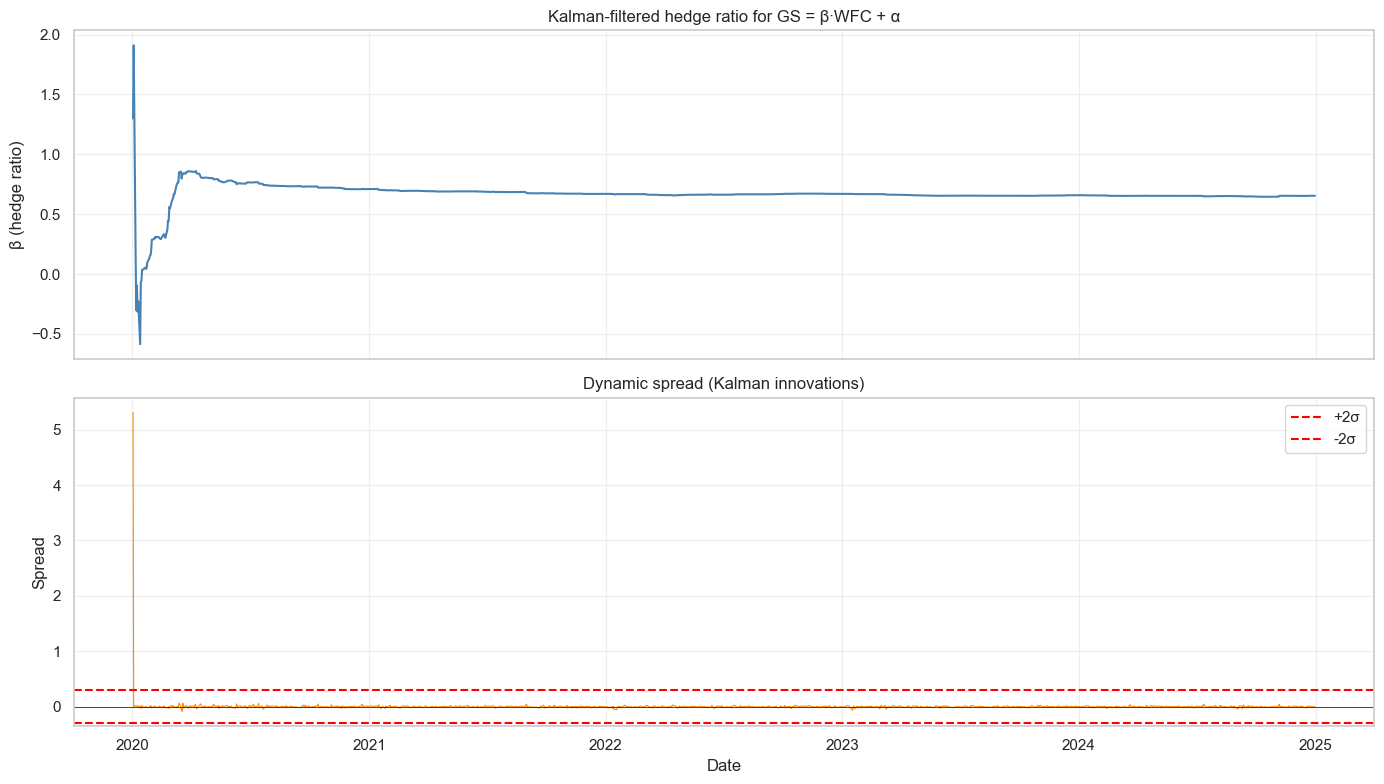


For GS/WFC:
  Static OLS p-value:       0.0020
  Dynamic spread ADF p:     0.0000
  Hedge ratio β: mean=0.667, std=0.112
  Spread std: 0.1503


In [5]:
best_pair = comparison_df.iloc[0]
y, x = best_pair["pair"].split("/")
result = kalman_results[(y, x)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(result.beta_series, color="steelblue")
axes[0].set_title(f"Kalman-filtered hedge ratio for {y} = β·{x} + α")
axes[0].set_ylabel(f"β (hedge ratio)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(result.spread, color="darkorange", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].axhline(2 * result.spread_std, color="red", linestyle="--", label="+2σ")
axes[1].axhline(-2 * result.spread_std, color="red", linestyle="--", label="-2σ")
axes[1].set_title(f"Dynamic spread (Kalman innovations)")
axes[1].set_ylabel("Spread")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFor {y}/{x}:")
print(f"  Static OLS p-value:       {best_pair['static_p']:.4f}")
print(f"  Dynamic spread ADF p:     {best_pair['dynamic_p']:.4f}")
print(f"  Hedge ratio β: mean={result.beta_series.mean():.3f}, "
      f"std={result.beta_series.std():.3f}")
print(f"  Spread std: {result.spread_std:.4f}")

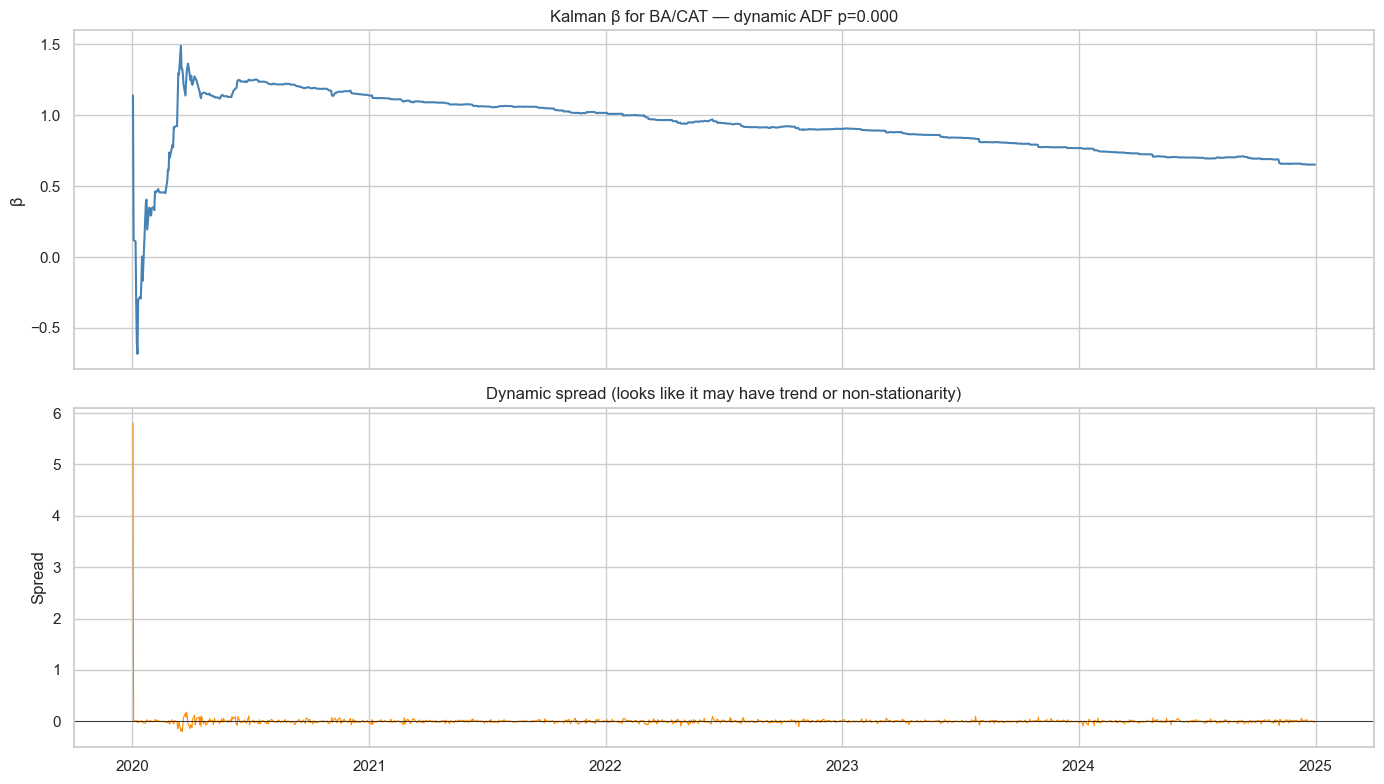

In [6]:
worst_pair = comparison_df.iloc[-1]
y, x = worst_pair["pair"].split("/")
result = kalman_results[(y, x)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(result.beta_series, color="steelblue")
axes[0].set_title(f"Kalman β for {y}/{x} — dynamic ADF p={worst_pair['dynamic_p']:.3f}")
axes[0].set_ylabel("β")
axes[1].plot(result.spread, color="darkorange", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("Dynamic spread (looks like it may have trend or non-stationarity)")
axes[1].set_ylabel("Spread")
plt.tight_layout()
plt.show()

In [7]:
import pickle

output_path = project_root / "data" / "processed" / "kalman_results.pkl"
with open(output_path, "wb") as f:
    pickle.dump(kalman_results, f)
print(f"Saved Kalman results for {len(kalman_results)} pairs to {output_path}")

# Also save the comparison table as a Parquet for the writeup.
comparison_df.to_parquet(project_root / "data" / "processed" / "kalman_comparison.parquet")

Saved Kalman results for 8 pairs to /home/vaibhav/Projects/pairs-trading/data/processed/kalman_results.pkl
